# Develop quick stuff

For temporary/quick stuff to be developed

In [1]:
import os
import sys

base_path = os.path.abspath("./..")
thesis_path = os.path.join(base_path, "thesis")
for p in [base_path, thesis_path]:
  if p not in sys.path:
      sys.path.append(p)

from IPython.display import display, Markdown
import torch


from experiments.acceptance_loop_cv_based_MNAR import THRESHOLD_BASIS, METRIC_CATEGORIES, EXPECTATION_TYPES, REAL_PERFORMANCE_TYPES
from berebasl.simulation.credit_data_simulation import CreditDataGenerator, GaussianMixture

In [2]:
os.chdir(base_path)
%run "thesis/helper_scripts/general.py"

In [9]:
os.chdir(thesis_path)


grid_path = '../berebasl/data/simulations/mnar_grid_hyp_vec'
grid_biases = extract_biases_from_dirnames(grid_path)

all_sim_objs = extract_all_sim_objs_vec(grid_path, grid_biases)
all_corrs = torch.stack([sim_objs['corr_to_hidden'] for sim_objs in all_sim_objs.values()], dim=0)
assert torch.all(all_corrs[[0]] == all_corrs)

base_sim_bias = '0_0'
base_sim = all_sim_objs[base_sim_bias]
print(base_sim["credit_data"].accepted.shape)
wished_corr = -0.4
base_sim_objs = slice_vec_sim(base_sim, wished_corr)

base_dgp_unsliced = base_sim["data_generator"]
dgp_base = base_sim_objs["data_generator"]

torch.Size([7, 306000])


In [42]:
from copy import deepcopy
all_diffs = {b : generate_lines_for_diffs_vec(sim, make_abs=True, W=5) for b, sim in all_sim_objs.items()}
exp_to_real_diffs_base = deepcopy(all_diffs[base_sim_bias])
idx_wished_cor = torch.where(base_sim['corr_to_hidden'] == wished_corr)[0].item()
exp_to_real_diffs_base["diff_data"] = {
    lbl : {
        c : {
            d_type : diff if diff is None else diff[idx_wished_cor]
            for d_type, diff in c_diffs.items()
        }
        for c, c_diffs in lbs_diff_data.items()
    }
    for lbl, lbs_diff_data in exp_to_real_diffs_base["diff_data"].items()
}

In [76]:
exp_to_real_diffs_base["diff_data"]['oracle_naive_roc']["perf_bayes"]["diffs"].nanmean(dim=-1)

tensor(0.0064, dtype=torch.float64)

In [82]:
from typing import Dict, Tuple

biases = grid_biases

expectation_types=EXPECTATION_TYPES
metric_categories=METRIC_CATEGORIES
diff_types=["diffs"]

def construct_all_diffs_tensor_vec(
    all_diffs,
    biases: Dict[str, float],
    expectation_types: list,
    metric_categories: list,
    diff_types: list,
) -> Tuple[torch.Tensor, int, int, int, int, int]:
    all_diffs_list = []
    for b_s in biases.keys():
        diff_data_b = all_diffs[b_s]["diff_data"]
        for e in expectation_types:
            for m in metric_categories:
                case_lbl = e + '_' + m
                diff_data_current = diff_data_b[case_lbl]
                classifs = diff_data_current.keys()
                for classif in classifs:
                    for dt in diff_types:
                        all_diffs_list.append(diff_data_current[classif][dt])

    B = len(biases)
    E = len(expectation_types)
    M = len(metric_categories)
    Cl = len(classifs)  # logit, bayes
    D = len(diff_types)
    sample_sizes = next(all_diffs.values().__iter__())["sample_sizes"]
    N = sample_sizes.size(0)

    all_diffs_ten = torch.stack(all_diffs_list, dim=0)
    print(all_diffs_ten.shape)
    Co = all_diffs_ten.size(1)

    all_diffs_ten = all_diffs_ten.reshape(B, E, M, Cl, D, Co, N)
    all_diffs_ten = all_diffs_ten.movedim(-2, 1) # [B, Co, E, M, Cl, D, N]


    print(torch.all(all_diffs_list[1] == all_diffs_ten[0,:,0,0,1,0]))

    return all_diffs_ten, sample_sizes, B, Co, E, M, Cl, D


all_diffs_new, sample_sizes, B, Co, E, M, Cl, D = construct_all_diffs_tensor_vec(
        all_diffs,
        biases=grid_biases,
        expectation_types=EXPECTATION_TYPES,
        metric_categories=METRIC_CATEGORIES,
        diff_types=diff_types
    )

torch.Size([90, 7, 300])
tensor(False)


In [89]:
base_sim["stats"]['acc_based_roc_thresholds']

tensor([[[[0.1946, 0.1682, 0.1998, 0.3596, 0.1415],
          [0.4131, 0.1970, 0.1674, 0.2902, 0.1466],
          [0.1948, 0.1548, 0.1930, 0.1747, 0.1598],
          ...,
          [0.1528, 0.2352, 0.1235, 0.2114, 0.1831],
          [0.1519, 0.1201, 0.2199, 0.1859, 0.2101],
          [0.1941, 0.1285, 0.1892, 0.1924, 0.2540]],

         [[0.1755, 0.1241, 0.1987, 0.1691, 0.2215],
          [0.1689, 0.2315, 0.1714, 0.1527, 0.1883],
          [0.1794, 0.1242, 0.1912, 0.1765, 0.1775],
          ...,
          [0.1003, 0.2168, 0.2474, 0.2080, 0.1316],
          [0.1746, 0.1825, 0.1581, 0.1622, 0.1757],
          [0.1699, 0.1901, 0.1696, 0.1781, 0.1834]],

         [[0.1955, 0.2406, 0.1391, 0.2195, 0.2127],
          [0.1803, 0.1301, 0.2388, 0.1697, 0.2244],
          [0.1664, 0.1449, 0.2044, 0.2556, 0.1838],
          ...,
          [0.1847, 0.0998, 0.2364, 0.1688, 0.3233],
          [0.1700, 0.1850, 0.2430, 0.1686, 0.1538],
          [0.1565, 0.1793, 0.2152, 0.1634, 0.2667]],

         ...,

In [85]:
def construct_all_diffs_tensor_vec(
    all_diffs,
    biases: Dict[str, float],
    expectation_types: list,
    metric_categories: list,
    diff_types: list,
    debug: bool = False,
) -> Tuple[torch.Tensor, int, int, int, int, int]:

    all_diffs_list = []
    for b_s in biases.keys():
        diff_data_b = all_diffs[b_s]["diff_data"]
        for e in expectation_types:
            for m in metric_categories:
                case_lbl = e + '_' + m
                diff_data_current = diff_data_b[case_lbl]
                classifs = list(diff_data_current.keys())
                for cl in classifs:
                    for dt in diff_types:
                        all_diffs_list.append(diff_data_current[cl][dt])

    B = len(biases)
    E = len(expectation_types)
    M = len(metric_categories)
    Cl = len(classifs)
    D = len(diff_types)

    sample_sizes = next(all_diffs.values().__iter__())["sample_sizes"]
    N = sample_sizes.size(0)

    # Stack
    all_diffs_ten = torch.stack(all_diffs_list, dim=0)
    Co = all_diffs_ten.size(1)

    # Reshape + move Co axis
    all_diffs_ten = all_diffs_ten.reshape(B, E, M, Cl, D, Co, N)
    all_diffs_ten = all_diffs_ten.movedim(-2, 1)  # [B, Co, E, M, Cl, D, N]

    # ---------------------------------------------------------
    # DEBUG MODE
    # ---------------------------------------------------------
    if debug:
        print("DEBUG MODE ENABLED — verifying ordering and equality")

        # Check every index
        flat_idx = 0
        for b in range(B):
            for e in range(E):
                for m in range(M):
                    for cl in range(Cl):
                        for dt in range(D):

                            # Check equality
                            ok = torch.allclose(all_diffs_list[flat_idx], all_diffs_ten[b, :, e, m, cl, dt], rtol=0, atol=0, equal_nan=True)
                            

                            print(
                                f"[b={b}, e={e}, m={m}, cl={cl}, dt={dt}] "
                                f"flat_idx={flat_idx} → equal={ok}"
                            )

                            if not ok:
                                raise ValueError(
                                    f"Mismatch at index "
                                    f"(b={b}, e={e}, m={m}, cl={cl}, dt={dt})"
                                )

                            flat_idx += 1

        print("All debug checks passed — ordering and data integrity verified.")

    return all_diffs_ten, sample_sizes, B, Co, E, M, Cl, D

all_diffs_new, sample_sizes, B, Co, E, M, Cl, D = construct_all_diffs_tensor_vec(
        all_diffs,
        biases=grid_biases,
        expectation_types=EXPECTATION_TYPES,
        metric_categories=METRIC_CATEGORIES,
        diff_types=diff_types,
        debug=True
    )

DEBUG MODE ENABLED — verifying ordering and equality
[b=0, e=0, m=0, cl=0, dt=0] flat_idx=0 → equal=True
[b=0, e=0, m=0, cl=1, dt=0] flat_idx=1 → equal=True
[b=0, e=0, m=0, cl=2, dt=0] flat_idx=2 → equal=True
[b=0, e=0, m=1, cl=0, dt=0] flat_idx=3 → equal=True
[b=0, e=0, m=1, cl=1, dt=0] flat_idx=4 → equal=True
[b=0, e=0, m=1, cl=2, dt=0] flat_idx=5 → equal=True
[b=0, e=1, m=0, cl=0, dt=0] flat_idx=6 → equal=True
[b=0, e=1, m=0, cl=1, dt=0] flat_idx=7 → equal=True
[b=0, e=1, m=0, cl=2, dt=0] flat_idx=8 → equal=True
[b=0, e=1, m=1, cl=0, dt=0] flat_idx=9 → equal=True
[b=0, e=1, m=1, cl=1, dt=0] flat_idx=10 → equal=True
[b=0, e=1, m=1, cl=2, dt=0] flat_idx=11 → equal=True
[b=0, e=2, m=0, cl=0, dt=0] flat_idx=12 → equal=True
[b=0, e=2, m=0, cl=1, dt=0] flat_idx=13 → equal=True
[b=0, e=2, m=0, cl=2, dt=0] flat_idx=14 → equal=True
[b=0, e=2, m=1, cl=0, dt=0] flat_idx=15 → equal=True
[b=0, e=2, m=1, cl=1, dt=0] flat_idx=16 → equal=True
[b=0, e=2, m=1, cl=2, dt=0] flat_idx=17 → equal=True
[b=

In [58]:
os.chdir(base_path)
%run "thesis/helper_scripts/hypothesis_visualization.py"

In [ ]:
## [B, Co, E, M, Cl, D, N]

all_diffs_new, sample_sizes, B, Co, E, M, Cl, D = construct_all_diffs_tensor_vec(
        all_diffs,
        biases=grid_biases,
        expectation_types=EXPECTATION_TYPES,
        metric_categories=METRIC_CATEGORIES,
        diff_types=diff_types
    )



torch.Size([5, 7, 3, 2, 3, 1, 300])
3


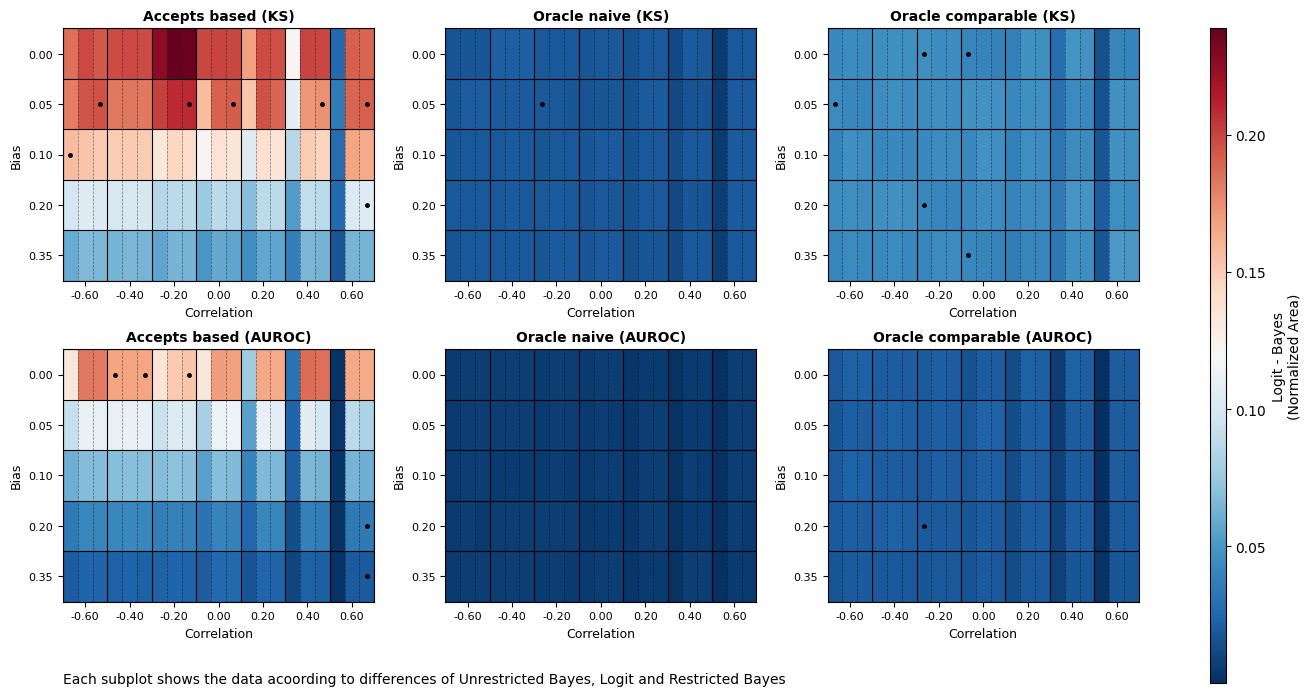

In [86]:
def wrapper_plot_grid_of_diffs_between_logit_and_acc_vec(all_diffs, grid_biases, grid_corrs):
    vals_classifs = list(
        all_diffs.values().__iter__().__next__()["diff_data"].values().__iter__().__next__().keys()
    )
    classif_meaning = {
        "logit" : "Logit",
        "bayes" : "Perfect Bayes",
        'perf_bayes' : "Unrestricted Bayes",
        'restricted_bayes' : "Restricted Bayes"
    }
    diff_types = ["diffs"]
    # Construct all_diffs tensor
    ## [B, Co, E, M, Cl, D, N], [N]
    all_diffs_new, sample_sizes, B, Co, E, M, Cl, D = construct_all_diffs_tensor_vec(
        all_diffs,
        biases=grid_biases,
        expectation_types=EXPECTATION_TYPES,
        metric_categories=METRIC_CATEGORIES,
        diff_types=diff_types
    )


    # Get areas
    idx_abs_diffs = 0
    print(all_diffs_new.shape)
    normed_areas = all_diffs_new[..., idx_abs_diffs, :].nanmean(dim=-1) # [B, Co, E, M, Cl]

    idx_logit = 1
    normed_areas_logit = normed_areas[..., idx_logit]
    mask_is_smaller_than_logit = normed_areas_logit.unsqueeze(-1) < normed_areas


    def custom_title_mapping(e_type: str, m_cat: str) -> str:
        e_type_map = {
            "acc_based" : "Accepts based",
            "oracle_naive" : "Oracle naive",
            "oracle_comparable" : "Oracle comparable"
        }
        m_cat_mapper = {
            "roc" : "AUROC",
            "ks" : "KS"
        }
        return f'{e_type_map[e_type]} ({m_cat_mapper[m_cat]})'

    plot_heatmap_grid_multiD(
        data=normed_areas,
        mask_set_point=mask_is_smaller_than_logit,
        metric_categories=METRIC_CATEGORIES,
        expectation_types=EXPECTATION_TYPES,
        biases=grid_biases,
        corrs=grid_corrs,
        cmap="RdBu_r",
        suptitle="",
        title_bold=True,
        cbar_label="Logit - Bayes\n(Normalized Area)",
        title_mapping=custom_title_mapping,
        d_lbls=[classif_meaning[c] for c in vals_classifs]
    )
wrapper_plot_grid_of_diffs_between_logit_and_acc_vec(
    all_diffs,
    grid_biases,
    grid_corrs={str(v.item()).replace(".", "_") : v.item() for v in  base_sim["corr_to_hidden"].msort()}
)

In [62]:
from typing import Optional, Dict
from berebasl.simulation.credit_data_simulation import CreditData

def get_acc_defaults_per_round_vec(sim_objs) -> Dict[str, torch.Tensor]:
    acc_flags = gather_all_acc_flags(sim_objs)
    credit_data: CreditData = sim_objs["credit_data"]

    rounds = credit_data.gen_round.expand_as(credit_data.accepted)
    G = credit_data.last_gen_round + 1 # Count rounds

    new_zeros_shape = credit_data.accepted.shape[:-1] + (G,)
    

    boolean_def_flag = credit_data.default_flag.to(bool)

    return {
        k : v.new_zeros(new_zeros_shape, dtype=torch.int32).scatter_add_(
            dim=-1,
            index=rounds,
            src=(v & boolean_def_flag).to(torch.int32)
        )
        for k, v in acc_flags.items()
    }

def generate_lines_for_diffs_vec(
        sim_objs: Dict[str, torch.Tensor],
        make_abs: bool = False,
        W: Optional[int] = None
):
    add_ma = W is not None
    if add_ma:
        W = int(W)

    Co = base_sim['corr_to_hidden'].size(0)

    stats = sim_objs["stats"]

    bayes_stats = {
        "perf_bayes" : sim_objs["perf_bayes_stats"],
        "restricted_bayes" : sim_objs["perf_bayes_missing_stats"]
    }

    exp_to_real_diffs_complete = {
        "sample_sizes" : sim_objs["sample_sizes"],
        "diff_data" : {}
    }

    mask_no_bads_among_acc = {
        k : v == 0 for k, v in get_acc_defaults_per_round_vec(sim_objs).items()
    }
    
    exp_to_real_diffs = exp_to_real_diffs_complete["diff_data"]

    for exp in EXPECTATION_TYPES:
        for m in METRIC_CATEGORIES:
            current_lbl = exp + '_' + m
            exp_to_real_diffs[current_lbl] = {
                c : {
                    "diffs" : None,
                    "ma_diffs" : None
                }
                for c in ["logit"] + list(bayes_stats.keys())
            }

            # 1. CV x K lines - plot all cv lines of the expectation
            exp_lbl = exp+'_'+m+'_stats'

            th_is_oracle = exp.startswith("oracle")
            th = "oracle" if th_is_oracle else exp
            assert th in THRESHOLD_BASIS, "Threshold logic changed"

            for perf in REAL_PERFORMANCE_TYPES:
                perf_is_unb_future = perf=="unbiased_future"
                should_add = False
                if exp == 'acc_based':
                    should_add = perf == "biased_acc"
                elif exp == 'oracle_naive':
                    should_add = perf == "unbiased_future"
                elif exp=='oracle_comparable':
                    should_add = perf == 'unbiased_acc'
                
                if perf_is_unb_future:
                    real_lbl_stats = perf+ '_' + th
                    if not th_is_oracle:
                        # If not oracle, the available history also depend on the basis
                        # of the threshold metric and can/should generate different
                        # scores which of course **do** affect the realized performance
                        real_lbl_stats += "_" + m # Make sure based on same metric for acc-based
                    real_lbl_stats += '_real_' + m
                    realized_logit = stats[real_lbl_stats].T # [Co, gen]
                    realized_bayes = {
                        bn : (
                            b_s[real_lbl_stats][:, 1:]
                            if b_s[real_lbl_stats].size(0) == Co else
                            b_s[real_lbl_stats][::2, 1:]
                        ) # [Co, gen]
                        for bn, b_s in bayes_stats.items()
                    }
                else:
                    # This branch is evaluation on accepts, either biased or unbiased
                    # therefore they are also dependent on the metric used as basis
                    # for the decision and it must be considered in the thresholding
                    # calculation - which was done -. `th + "_" + m` makes sure we
                    # get the realized performance on the right accepts
                    real_lbl_stats = perf+ '_' + th + "_" + m + '_real_' + m
                    mask_make_nan = mask_no_bads_among_acc[th+'_'+m][..., 1:] # [Co, Gen]
                    realized_logit = stats[real_lbl_stats][:, -1].T.masked_fill(mask_make_nan, float('nan'))  # [Co, Gen]
                    realized_bayes = {
                        bn : (
                            b_s[real_lbl_stats][:, 1:]
                            if b_s[real_lbl_stats].size(0) == Co else
                            b_s[real_lbl_stats][::2, 1:]
                        ).masked_fill(mask_make_nan, float('nan'))
                        for bn, b_s in bayes_stats.items()
                    }

                if should_add:
                    for expectation, realization, c in (
                        [(stats[exp_lbl].movedim(-2, 0), realized_logit, "logit")] +
                        [(bayes_stats[bn][exp_lbl][:, 1:], realized_bayes[bn], bn) for bn in bayes_stats.keys()]
                    ):
                        exp_to_real_diffs[current_lbl][c]["diffs"] = calc_diffs(expectation, realization)
                        if make_abs:
                            exp_to_real_diffs[current_lbl][c]["diffs"].abs_()

                        if add_ma:
                            exp_to_real_diffs[current_lbl][c]["ma_diffs"] = moving_average_with_nans(
                                exp_to_real_diffs[current_lbl][c]["diffs"], W, dim=-1, with_tails=True
                            )

    return exp_to_real_diffs_complete


diffs = generate_lines_for_diffs_vec(base_sim)

In [69]:
all_diffs = {b : generate_lines_for_diffs_vec(sim) for b, sim in all_sim_objs.items()}

In [67]:
colors

{'exp': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'exp_bayes': (1.0, 0.4980392156862745, 0.054901960784313725),
 'biased_acc': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'unbiased_acc': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'unbiased_future': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'real_bayes': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)}

In [64]:
for lbl, diff_data in diffs["diff_data"].items():
    break

In [68]:
diff_data.keys()

dict_keys(['logit', 'perf_bayes', 'restricted_bayes'])

In [183]:
from berebasl.simulation.credit_data_simulation import CreditData

credit_data: CreditData = base_sim['credit_data']

In [186]:
credit_data.features.shape, credit_data.default_flag.shape, credit_data.accepted.shape, credit_data.gen_round.shape

(torch.Size([7, 306000, 3]),
 torch.Size([7, 306000]),
 torch.Size([7, 306000]),
 torch.Size([306000]))

In [ ]:
base_sim.keys()

dict_keys(['Description', 'corr_to_hidden', 'bias_prop', 'stats', 'perf_bayes_stats', 'perf_bayes_missing_stats', 'alternative_accepted', 'sample_sizes', 'credit_data', 'data_generator', 'k_folds', 'cv_count', 'var_to_hide'])

In [ ]:
from thesis.helper_scripts.sensitivity_analysis import extract_bayes_errors, wrapper_bayes_errors_plot
from thesis.helper_scripts.hypothesis_visualization import (
  plot_lines_and_mains,
  generate_line_collections_for_exp_real_plot,
  generate_lines_for_diffs,
  gen_lines_from_diff_dict,
  construct_all_diffs_tensor,
  get_areas,
  normalize_areas,
  plot_heatmap_grid,
  wrapper_plot_grid_of_diffs_between_logit_and_acc,
  plot_acc_rates_per_round
)
from thesis.helper_scripts.dgp_plotting import (
  extract_dgp_info_for_boundaries,
  plot3d_with_perf_bayes_boundary,
  plot_pairwise_dgp_with_perf_bayes_boundaries
)